# SUBSET-SUM PROBLEM WITH GROVER'S ALGORITHM

#### 1. Statement of Problem

To develop a function that takes a finite set of positive integers, $S = \{x_0, x_1, \dots, x_{n-1}\}$, and a positive integer $t$, and outputs subsets $I_j \subseteq S$ for some $j\in J$ (an index set), that satisfies $\sum_{x_i \in I_j} x_i = t$, or decides with high probability, that no such set exists.

For example, if $S = \{1,2,3,4,5,6\}$, and $t = 10$, then the valid outputs are  $I_1 = \{1,2,3,4\}, I_2 = \{2,3,5\}, I_3 = \{1,4,5\}, I_4 = \{1,3,6\}, \text{ and }I_5 = \{4,6\}$



### 2. Complexity of Problem

Given a nonempty subset $S$ having $n$ elements, the power set of $S$, defined as the set of all possible subsets has cardinality $2^n$.

Classically, the problem will involve checking all possible subsets of $S$ in the worse case scenerio. Hence, this brute force method has the exponential time complexity $O(2^n)$.

Grover's algorithm requires about $O(\sqrt{2^n})$ operations, which is a polynomial speedup over the classical approach. 

### 3. Relevant Imports

In [8]:
import numpy as np
import sympy as sp
from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import pylatexenc
from IPython.display import display
from qiskit.circuit.library import MCMTGate, XGate, MCPhaseGate

### 4. Search for Valid Subsets

We first define a fuction that finds the valid subsets of $S$ that satisfy the condition and encodes these sets in binary.

In [9]:
def find_valid_subsets(S, t):
    n = len(S)
    answer_set = []
    for i in range(2**n):
        my_sum = sum(S[k] for k in range(n) if (i >> k) & 1)
        if my_sum == t:
            answer_set.append(format(i, f'0{n}b'))
    return answer_set


### 5. The Marker Oracle

The marker oracle will flag the state representing each valid subset by flipping its phase to $-1$. We note that due to the  little-endian convention for bit ordering in qiskit, we will need to reverse the order of the bit-encode of each valid subset.



In [10]:
def build_oracle_gate(qubits, ancillas, answer_set):
    oracle_circuit = QuantumCircuit(qubits, ancillas, name="oracle")
    for subset in answer_set:
        for index, bit in enumerate(reversed(subset)):
            if bit == '0':
                oracle_circuit.x(qubits[index])

        ctrls = list(qubits)
        tgts = [ancillas[j] for j, bit in enumerate(reversed(subset)) if bit == '1']
        if tgts:
            gate = MCMTGate(XGate(), len(ctrls), len(tgts))
            oracle_circuit.append(gate, ctrls + tgts)

        for index, bit in enumerate(reversed(subset)):
            if bit == '0':
                oracle_circuit.x(qubits[index])

    return oracle_circuit.to_gate()


### 6. The Diffuser

The diffuser oracle first places all the states representing each subset in the $\ket{+}$ states, achieved by the application of the Hadamard gate to every qubit. This creates a uniform superposition over all bit strings. The next is to apply the multiple controlled phase gate (which here is implemented using  the Hadmard and Multi-controlled-$X$ gates). This proccess creates a reflection about the mean (which at first is the initial superposition). Finally, we uncompute (by applying the $X$ and Hadamard gates).

In [11]:
def build_diffuser(qubits):
    diffuser = QuantumCircuit(qubits, name="diffuser")
    n = len(qubits)

    diffuser.h(qubits)
    diffuser.x(qubits)

    # Reflection about |0...0>: apply Z to |11...1> in the X-basis
    if n == 1:
        diffuser.z(qubits)
    else:
        diffuser.h(qubits[-1])
        diffuser.mcx(list(qubits[:-1]), qubits[-1])
        diffuser.h(qubits[-1])

    diffuser.x(qubits)
    diffuser.h(qubits)
    return diffuser

### 7. The Full Grover's Algorithm

In this last step, we utilize apply Steps 4-6 to create the full Grover's circuit for the problem by adding each the marker and difuser oracles to the gate. The optimal number of times the diffuser oracle will run is $\Big \lfloor \tfrac{\pi}{4 \arcsin(1 / \sqrt{N})} - \tfrac{1}{2} \Big \rfloor$, where $N = 2^n$. For large $N$, this is about $\lfloor \tfrac{\pi}{4}N \rfloor$ times. The code includes circuit diagrams for the preparatory, marker, diffuser, and full Grover circuits, but only the final (full) circuit is actually rendered in the output.

In [12]:
def subset_sum(S, t):
    n = len(S)

    # Handle empty input set before building quantum registers.
    if n == 0:
        if t == 0:
            print("The subset of [] that sum up to 0 is: []")
        else:
            print(f"No subset of [] satisfies the condition for target {t}")
        return

    answer_set = find_valid_subsets(S, t)

    answer_values = []
    for bits in answer_set:
        chosen = [S[i] for i, bit in enumerate(reversed(bits)) if bit == '1']
        answer_values.append(chosen)

    if answer_values:
        if len(answer_values) == 1:
            print(
                f"The subset of {S} that sum up to {t} is:",
                ", ".join(str(i) for i in answer_values)
            )
        else:
            print(
                f"The subsets of {S} that sum up to {t} are:",
                ", ".join(str(i) for i in answer_values)
            )
    else:
        print(f"No subset of {S} satisfies the condition")
        return

    q = QuantumRegister(n, name="q")
    a = AncillaRegister(n, name="a")

    prep = QuantumCircuit(q, name="prep")  # The preparatory stage
    prep.h(q)

    P = prep.to_gate()
    # print("The preparatory circuit is given below:")
    # display(prep.draw(output='mpl'))

    oracle_gate = build_oracle_gate(q, a, answer_set)  # The marker stage
    # print("The marker oracle circuit is displayed below:")
    # display(oracle_gate.definition.draw(output='mpl'))

    D = build_diffuser(q).to_gate()   # The diffuser stage
    # print("The diffuser circuit is displayed below")
    # display(D.definition.draw(output='mpl'))

    N = 2**n
    K = int(np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(N))) - 1 / 2)) # This is the optimum number of times the diffuser and marker circuits will be implemented

    grover = QuantumCircuit(q, a, name="Grover")  # The full grover algorithm
    grover.append(P, list(q))

    for _ in range(K):
        grover.barrier()
        grover.append(oracle_gate, list(q) + list(a))
        grover.barrier()
        grover.append(D, list(q))
    if K == 1:
        print(f"The full Grover circuit for the problem for 1 iteration is shown below")
        display(grover.draw(output='mpl'))
    else:
        print(f"The full Grover circuit for the problem for {K} iterations is shown below")
        display(grover.draw(output='mpl'))

    psi = Statevector(grover)
    probs = psi.probabilities()
    display(np.round(probs, 4))
    return grover

### 8. Examples

Example 0:
The subset of [] that sum up to 0 is: []
Example 1:
The subset of [1, 2, 3] that sum up to 5 is: [2, 3]
The full Grover circuit for the problem for 2 iterations is shown below


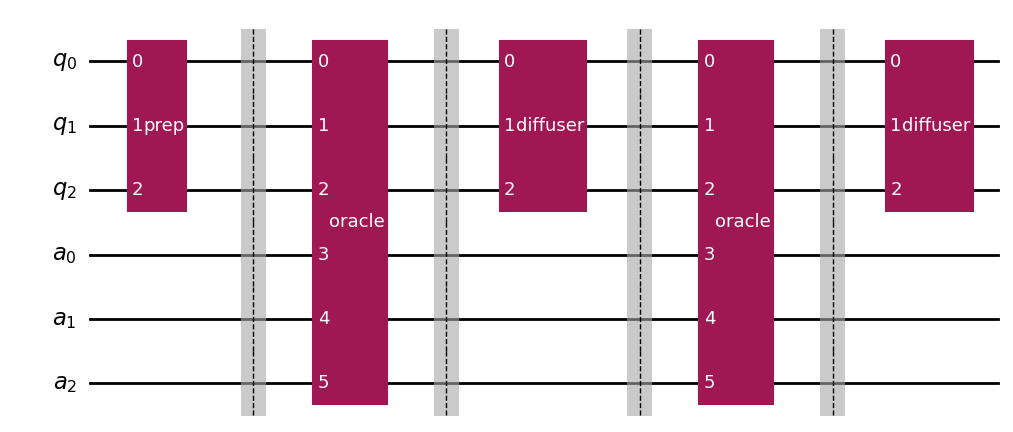

array([0.0176, 0.0176, 0.0176, 0.0176, 0.0176, 0.0176, 0.4395, 0.0176,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.0488, 0.0488, 0.0488, 0.0488, 0.0488, 0.0488, 0.0957, 0.0488,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ])

Example 2:
The subsets of [1, 2, 3, 4] that sum up to 7 are: [1, 2, 4], [3, 4]
The full Grover circuit for the problem for 3 iterations is shown below


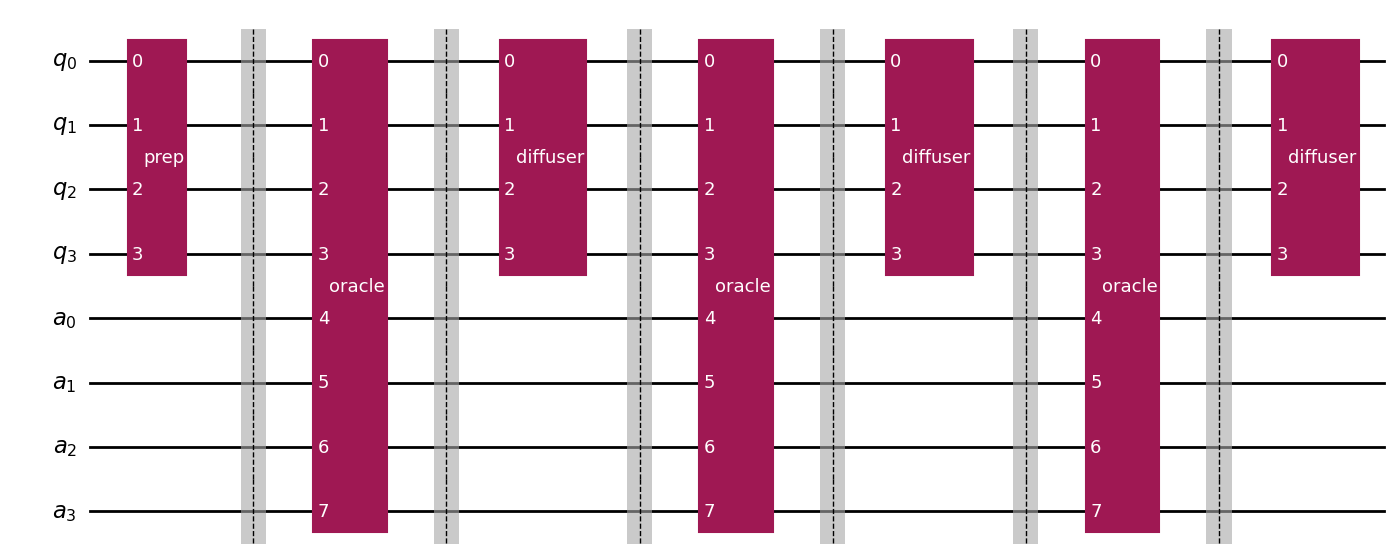

array([0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003,
       0.0003, 0.0003, 0.0003, 0.1572, 0.1572, 0.0003, 0.0003, 0.0003,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
      

Example 3:
The subsets of [1, 2, 3, 4, 5] that sum up to 10 are: [1, 2, 3, 4], [2, 3, 5], [1, 4, 5]
The full Grover circuit for the problem for 4 iterations is shown below


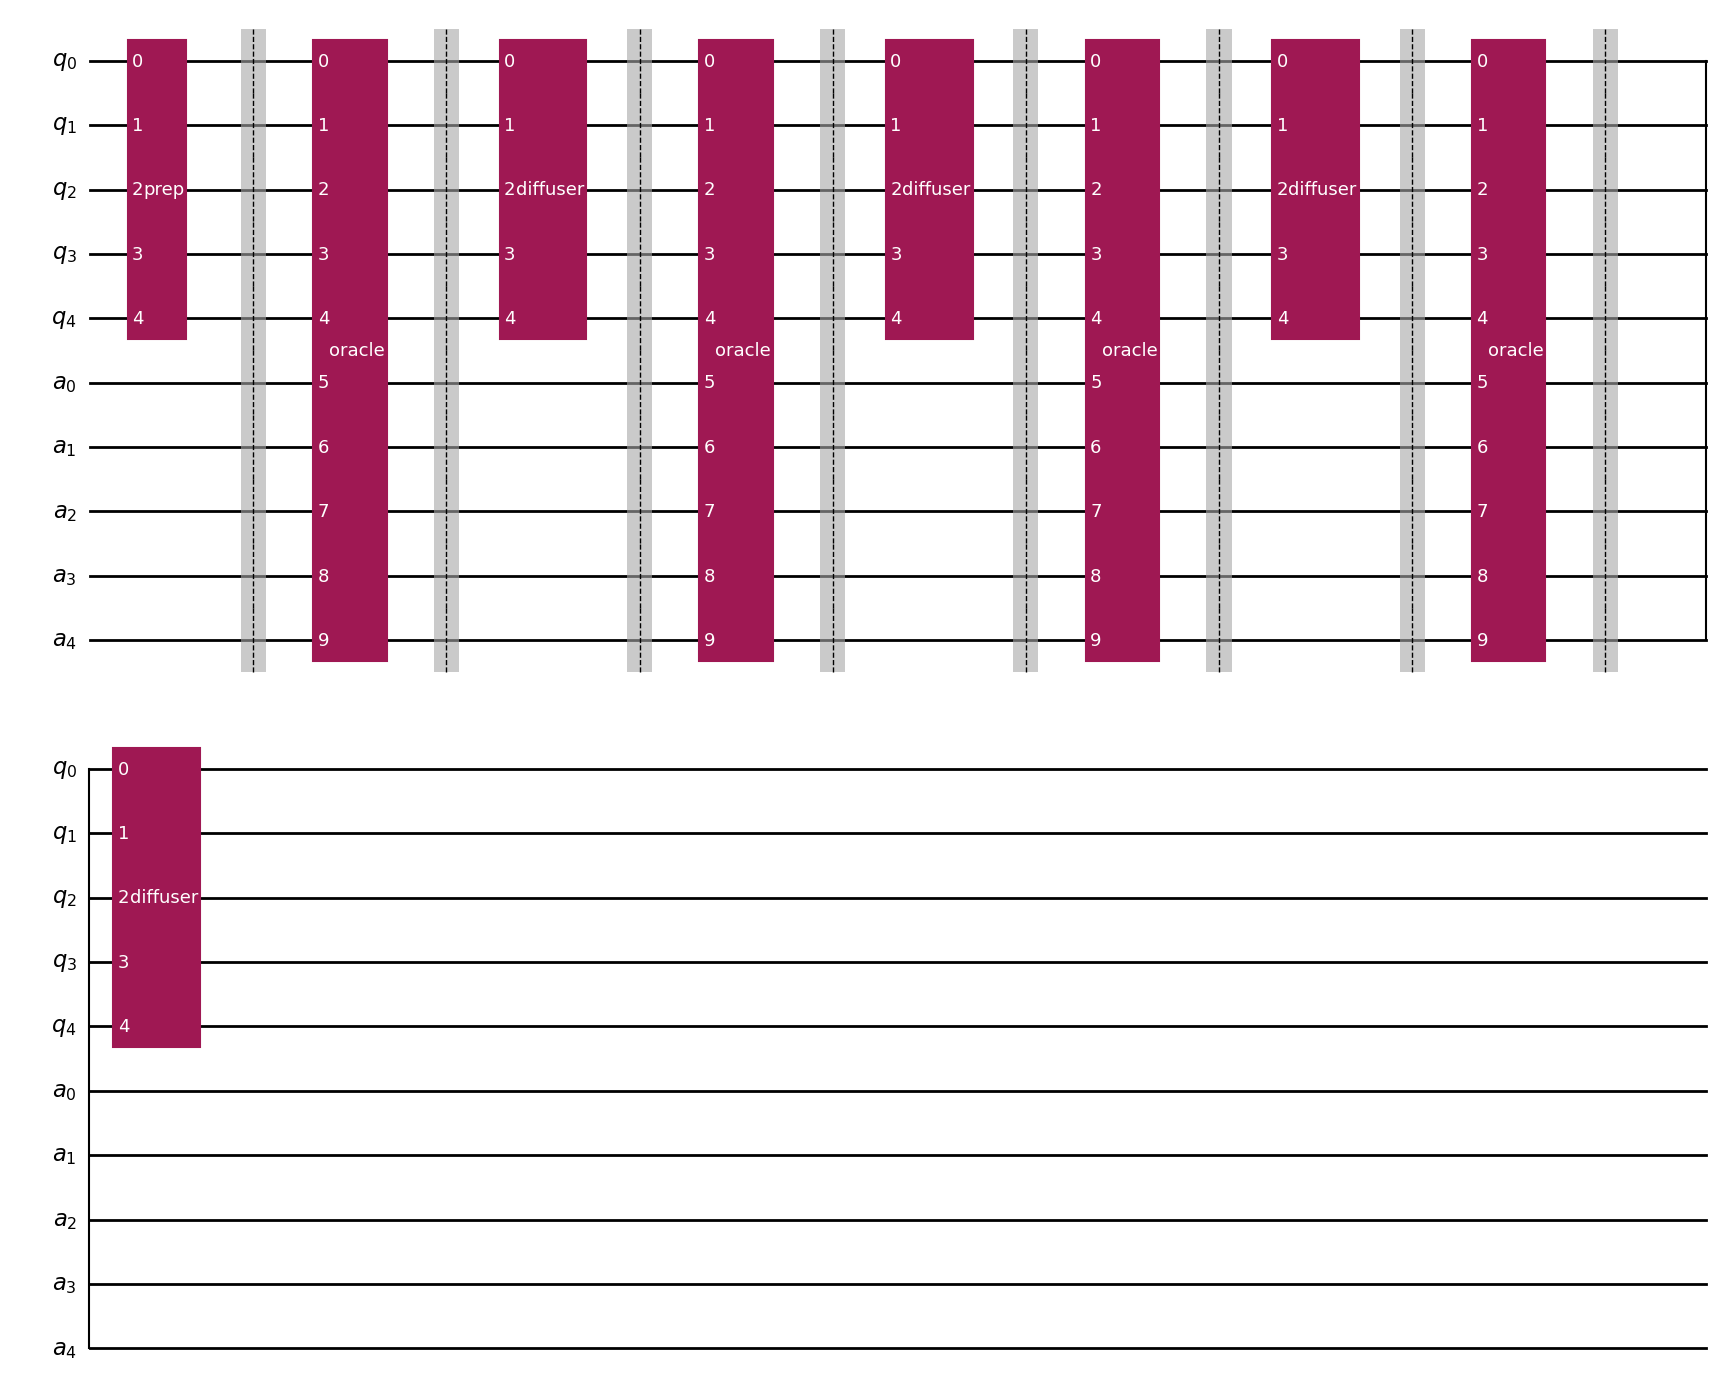

array([0.002, 0.002, 0.002, ..., 0.   , 0.   , 0.   ], shape=(1024,))

Example 4:
No subset of [1, 2, 3, 4, 5, 6] satisfies the condition


In [13]:
S_examples = [
    [],
    [1, 2, 3],
    [1, 2, 3, 4],
    [1, 2, 3, 4, 5],
    [1, 2, 3, 4, 5, 6]
]

t_examples = [0, 5, 7, 10, 100]

for i, (S, t) in enumerate(zip(S_examples, t_examples)):
    print(f"Example {i}:")
    subset_sum(S, t)